# 12 - Employee Skills Table

Day 3, step 12. The build notes flag a risk honestly, and it turned out to be real:

> "my current five datasets might not actually contain what skills each employee
> currently has. Without that, a real skill-gap calculation is impossible - I'd just
> be comparing role requirements to nothing."

**Checked, and confirmed: none of the five source datasets records per-employee
skills.** This notebook documents that check, then documents the controlled table
built in its place - which is the fallback the notes explicitly sanction.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from app.utils.config import PROCESSED_FILES, RAW_FILES
from app.validation.engagement_schema import validate_employee_skills_frame

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## The check: does skill data already exist?

In [2]:
sources = {
    "employee_attrition": pd.read_csv(RAW_FILES["attrition"], encoding="utf-8-sig"),
    "hr_performance_engagement": pd.read_csv(RAW_FILES["engagement"]),
    "occupation_data": pd.read_csv(RAW_FILES["occupation"]),
    "essential_skills": pd.read_csv(RAW_FILES["essential_skills"]),
    "software_skills": pd.read_csv(RAW_FILES["software_skills"]),
}

for name, frame in sources.items():
    columns = [c.strip() for c in frame.columns]
    skill_columns = [c for c in columns if "skill" in c.lower()]
    has_employee_key = any(c.lower() in {"employeeid", "employeenumber"} for c in columns)
    print(f"{name:28s} employee key: {str(has_employee_key):5s}  "
          f"skill columns: {skill_columns or '-'}")

employee_attrition           employee key: True   skill columns: -
hr_performance_engagement    employee key: True   skill columns: -
occupation_data              employee key: False  skill columns: -
essential_skills             employee key: False  skill columns: -
software_skills              employee key: False  skill columns: -


The result is unambiguous. The two files that mention skills - `essential_skills` and
`software_skills` - are keyed by **occupation**, not by employee. The two files keyed
by employee contain no skill columns at all. There is no table anywhere saying "this
person can do this thing".

So a genuine gap calculation is impossible from the source data alone, exactly as the
notes anticipated.

## The fallback: a controlled table

Built by `scripts/build_derived_sources.py`, in the long format the notes specify:

```
employee_id,current_skill
101,Python
101,SQL
```

with proficiency and provenance columns added, since they cost nothing and the
recommendation engine can use them later.

**What is real and what is not:**

| Component | Source |
|---|---|
| the skill vocabulary | real - O*NET 31.0 |
| which skills a role requires | real - O*NET importance ratings |
| how many skills an employee holds | modelled from real attributes (education, tenure, seniority, training) |
| *which specific employee holds which skill* | **synthesised**, seeded at 42 |

The mechanism is therefore genuine and the org-wide totals are illustrative. Numbers
like "879 employees are missing Active Learning" demonstrate that the engine works;
they are not measurements of a real workforce.

In [3]:
skills = pd.read_csv(PROCESSED_FILES["employee_skills"])
print(skills.shape)
skills.head(10)

(12388, 5)


,EmployeeID,SkillName,SkillType,AcquiredVia,ProficiencyLevel
0,1,Adobe Acrobat,Software Skill,Role,3
1,1,Adobe InDesign,Software Skill,Role,3
2,1,Critical Thinking,Essential Skill,Role,3
3,1,Microsoft Access,Software Skill,Transferable,2
4,1,Microsoft Excel,Software Skill,Role,2
5,1,Microsoft SharePoint,Software Skill,Transferable,2
6,2,Active Listening,Essential Skill,Role,3
7,2,ESRI ArcGIS,Software Skill,Role,3
8,2,Linux,Software Skill,Transferable,3
9,2,Microsoft Excel,Software Skill,Role,3


## Validating it like any other input

In [4]:
employees = pd.read_csv(PROCESSED_FILES["attrition"])
report = validate_employee_skills_frame(skills, valid_employee_ids=set(employees["EmployeeID"]))
print(report)

[PASS] employee_current_skills: 12,388 rows, 6 checks, 0 errors, 0 warnings


## Coverage

The question notebook 02 raised: is any employee missing from this table entirely?

In [5]:
covered = set(skills["EmployeeID"])
all_employees = set(employees["EmployeeID"])
print(f"employees with at least one skill : {len(covered):,} / {len(all_employees):,}")
print(f"employees with none               : {len(all_employees - covered)}")

per_employee = skills.groupby("EmployeeID").size()
print(f"\nskills per employee: min {per_employee.min()}, median "
      f"{per_employee.median():.0f}, max {per_employee.max()}, mean {per_employee.mean():.1f}")

employees with at least one skill : 1,470 / 1,470
employees with none               : 0

skills per employee: min 1, median 8, max 17, mean 8.4


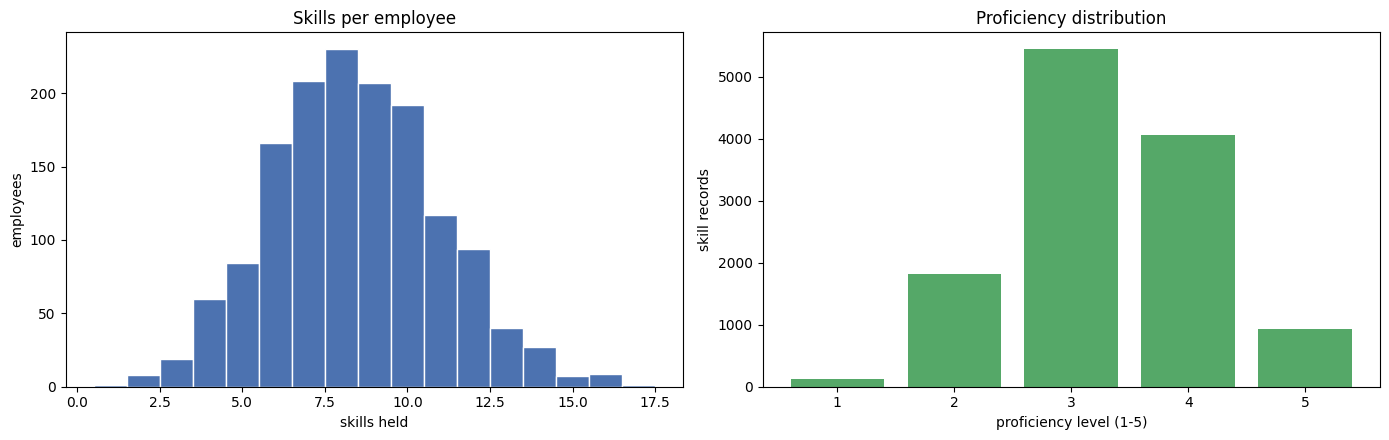

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.hist(per_employee, bins=range(int(per_employee.min()), int(per_employee.max()) + 2),
         color="#4C72B0", edgecolor="white", align="left")
ax1.set(xlabel="skills held", ylabel="employees", title="Skills per employee")

proficiency = skills["ProficiencyLevel"].value_counts().sort_index()
ax2.bar(proficiency.index, proficiency.values, color="#55A868")
ax2.set(xlabel="proficiency level (1-5)", ylabel="skill records", title="Proficiency distribution")
plt.tight_layout()
plt.show()

## Does the model behave as intended?

The generator was written so that more experienced, more senior, better-educated
employees hold more skills. Worth confirming rather than assuming - a bug here would
quietly bias every downstream gap.

In [7]:
merged = employees[["EmployeeID", "Education", "JobLevel", "TotalWorkingYears",
                    "TrainingTimesLastYear", "JobRole"]].merge(
    per_employee.rename("SkillsHeld"), left_on="EmployeeID", right_index=True, how="left")
merged["SkillsHeld"] = merged["SkillsHeld"].fillna(0)

for column in ["Education", "JobLevel"]:
    print(f"\n--- mean skills held by {column} ---")
    print(merged.groupby(column)["SkillsHeld"].agg(["mean", "count"]).round(2).to_string())


--- mean skills held by Education ---
            mean  count
Education              
1           6.95    170
2           7.87    282
3           8.42    572
4           9.20    398
5          10.58     48

--- mean skills held by JobLevel ---
           mean  count
JobLevel              
1          7.38    543
2          8.46    534
3          9.23    218
4         10.19    106
5         11.12     69


In [8]:
print("\ncorrelation of skills held with:")
for column in ["Education", "JobLevel", "TotalWorkingYears", "TrainingTimesLastYear"]:
    print(f"  {column:24s} {merged['SkillsHeld'].corr(merged[column]):+.4f}")


correlation of skills held with:
  Education                +0.3043
  JobLevel                 +0.4014
  TotalWorkingYears        +0.4015
  TrainingTimesLastYear    +0.0926


All four correlations are positive, so the intended relationship holds. `JobLevel` and
`TotalWorkingYears` dominate, which matches the weights in the generator.

## Most common skills held

In [9]:
common = (skills.groupby(["SkillName", "SkillType"]).size()
          .rename("EmployeesHolding").reset_index()
          .sort_values("EmployeesHolding", ascending=False))
common.head(15)

,SkillName,SkillType,EmployeesHolding
33,Microsoft Office,Software Skill,728
44,Reading Comprehension,Essential Skill,691
32,Microsoft Excel,Software Skill,688
1,Active Listening,Essential Skill,672
49,Speaking,Essential Skill,669
16,Critical Thinking,Essential Skill,656
51,Writing,Essential Skill,599
0,Active Learning,Essential Skill,591
35,Microsoft PowerPoint,Software Skill,516
40,Monitoring,Essential Skill,472


## Transferable skills

A minority of records are skills held outside the current role's requirements. These
matter for internal mobility - an employee already holding a skill another role needs
is a redeployment candidate, not a training candidate.

In [10]:
print(skills["AcquiredVia"].value_counts().to_string())
transferable = skills[skills["AcquiredVia"] == "Transferable"]
print(f"\n{transferable['EmployeeID'].nunique():,} employees hold at least one "
      f"skill outside their role's requirements")

AcquiredVia
Role            10951
Transferable     1437

956 employees hold at least one skill outside their role's requirements


## Replacing this table with real data

Nothing downstream reads the generator - the pipeline only reads the CSV. To swap in
a real skills inventory (from an LMS export, a self-assessment, or an HRIS), produce a
file with these columns and put it at `data/raw/employee_current_skills.csv`:

| Column | Required | Notes |
|---|---|---|
| `EmployeeID` | yes | must exist in the employee table |
| `SkillName` | yes | canonicalised by `skill_normalizer`, so raw spellings are fine |
| `SkillType` | no | Essential Skill / Software Skill |
| `AcquiredVia` | no | free text |
| `ProficiencyLevel` | no | 1-5 if present |

The validator in this notebook then applies unchanged, and every number downstream
becomes a real measurement rather than an illustration.